# Tutorial 11: DeepWalk and node2vec - Implementation details
  

Paper:
* [DeepWalk: Online Learning of Social Representation](https://arxiv.org/pdf/1403.6652.pdf)  
* [node2vec: Scalable Feature Learning for Networks](https://arxiv.org/pdf/1607.00653.pdf)  

Code:

 * [node2vec doc](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html?highlight=node2vec#torch_geometric.nn.models.Node2Vec)
 * [node2vec code](https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/nn/models/node2vec.html)
 * [Example on clustering](https://github.com/rusty1s/pytorch_geometric/blob/master/examples/node2vec.py)

# Setup

In [1]:
import os.path as osp

import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import Node2Vec
from tqdm.notebook import tqdm

In [2]:
dataset = 'Cora'
path = osp.join('.', 'data', dataset)
dataset = Planetoid(path, dataset)
data = dataset[0]

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Node2Vec(
    data.edge_index,
    embedding_dim=128,
    walk_length=20,  # lenght of rw
    context_size=10,
    walks_per_node=20,
    num_negative_samples=1,
    p=200,
    q=1,  # bias parameters
    sparse=True,
).to(device)

# Random walks

### The data loader

In [4]:
loader = model.loader(batch_size=128, shuffle=True, num_workers=4)

In [5]:
for idx, (pos_rw, neg_rw) in enumerate(loader):
    print(idx, pos_rw.shape, neg_rw.shape)

0 torch.Size([28160, 10]) torch.Size([28160, 10])
1 torch.Size([28160, 10]) torch.Size([28160, 10])
2 torch.Size([28160, 10]) torch.Size([28160, 10])
3 torch.Size([28160, 10]) torch.Size([28160, 10])
4 torch.Size([28160, 10]) torch.Size([28160, 10])
5 torch.Size([28160, 10]) torch.Size([28160, 10])
6 torch.Size([28160, 10]) torch.Size([28160, 10])
7 torch.Size([28160, 10]) torch.Size([28160, 10])
8 torch.Size([28160, 10]) torch.Size([28160, 10])
9 torch.Size([28160, 10]) torch.Size([28160, 10])
10 torch.Size([28160, 10]) torch.Size([28160, 10])
11 torch.Size([28160, 10]) torch.Size([28160, 10])
12 torch.Size([28160, 10]) torch.Size([28160, 10])
13 torch.Size([28160, 10]) torch.Size([28160, 10])
14 torch.Size([28160, 10]) torch.Size([28160, 10])
15 torch.Size([28160, 10]) torch.Size([28160, 10])
16 torch.Size([28160, 10]) torch.Size([28160, 10])
17 torch.Size([28160, 10]) torch.Size([28160, 10])
18 torch.Size([28160, 10]) torch.Size([28160, 10])
19 torch.Size([28160, 10]) torch.Size([28

In [6]:
idx, (pos_rw, neg_rw) = next(enumerate(loader))

In [7]:
idx

0

In [8]:
(pos_rw.shape, neg_rw.shape)

(torch.Size([28160, 10]), torch.Size([28160, 10]))

In [9]:
pos_rw

tensor([[2476,  564, 1262,  ...,  110, 1599, 2441],
        [2625, 2626, 2625,  ..., 2626, 2625, 2626],
        [ 433,  436,  483,  ..., 1351,  262, 1464],
        ...,
        [ 736,  734, 2197,  ..., 1117, 2499, 1524],
        [ 250, 2429,  250,  ..., 2429,  250, 2429],
        [1628, 2053,   52,  ..., 2182,  415, 2182]])

In [10]:
neg_rw

tensor([[2476, 1694, 2084,  ..., 2001, 1856,  122],
        [2625,  192, 1114,  ..., 1715, 2425,  500],
        [ 433,  753, 1180,  ..., 2091, 1218, 2545],
        ...,
        [ 227, 2033, 1927,  ..., 1511, 1531,  195],
        [1410, 1394,  741,  ..., 1331,  614, 1388],
        [ 627, 2188, 1987,  ..., 1434,  648, 2264]])

### Visualization

In [11]:
import networkx as nx

edge_tuples = [tuple(x) for x in data.edge_index.numpy().transpose()]
G = nx.from_edgelist(edge_tuples)
pos = nx.spring_layout(G, center=[0.5, 0.5])
nx.set_node_attributes(G, pos, 'pos')

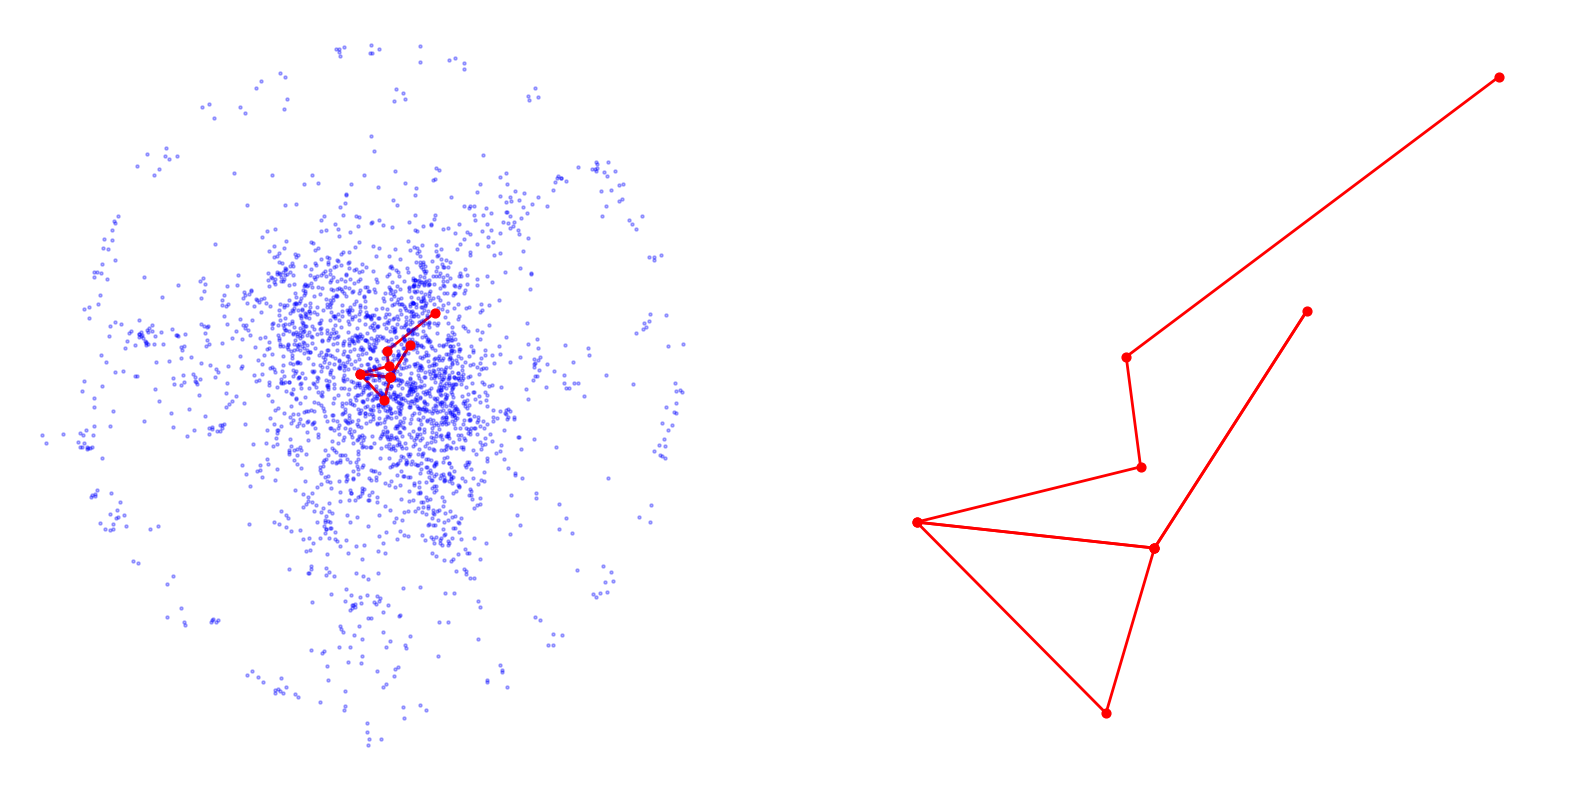

In [12]:
nodelist = next(enumerate(loader))[1][0][0].tolist()
walk = nx.path_graph(len(nodelist))
nx.set_node_attributes(
    walk, {idx: pos[node_id] for idx, node_id in enumerate(nodelist)}, 'pos'
)

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(1, 2, 1)
nx.draw_networkx_nodes(
    G,
    ax=ax,
    pos=nx.get_node_attributes(G, 'pos'),
    node_size=5,
    alpha=0.3,
    node_color='b',
)
nx.draw(
    walk,
    node_size=40,
    node_color='r',
    ax=ax,
    pos=nx.get_node_attributes(walk, 'pos'),
    width=2,
    edge_color='r',
)
ax = fig.add_subplot(1, 2, 2)
nx.draw(
    walk,
    node_size=40,
    node_color='r',
    ax=ax,
    pos=nx.get_node_attributes(walk, 'pos'),
    width=2,
    edge_color='r',
)

# Training

### Model definition

In [13]:
model = Node2Vec(
    data.edge_index,
    embedding_dim=128,
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1,
    q=1,
    sparse=True,
).to(device)

loader = model.loader(batch_size=128, shuffle=True, num_workers=4)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

### Training function

In [21]:
def train():
    model.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

### Test function

In [15]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [16]:
data.y

tensor([3, 4, 4,  ..., 3, 3, 3])

In [17]:
data.y.unique()

tensor([0, 1, 2, 3, 4, 5, 6])

In [18]:
@torch.no_grad()
def test():
    model.eval()
    z = model()
    acc = model.test(
        z[data.train_mask],
        data.y[data.train_mask],
        z[data.test_mask],
        data.y[data.test_mask],
        max_iter=150,
    )
    return acc

### Training

In [22]:
for epoch in range(1, 201):
    loss = train()
    acc = test()
    print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Acc: {acc:.4f}')

Epoch: 01, Loss: 8.1074, Acc: 0.1760
Epoch: 02, Loss: 6.0673, Acc: 0.2040
Epoch: 03, Loss: 4.9523, Acc: 0.2270
Epoch: 04, Loss: 4.1419, Acc: 0.2600
Epoch: 05, Loss: 3.4810, Acc: 0.2920
Epoch: 06, Loss: 2.9704, Acc: 0.3320
Epoch: 07, Loss: 2.5498, Acc: 0.3720
Epoch: 08, Loss: 2.2185, Acc: 0.3980
Epoch: 09, Loss: 1.9571, Acc: 0.4220
Epoch: 10, Loss: 1.7423, Acc: 0.4520
Epoch: 11, Loss: 1.5727, Acc: 0.4680
Epoch: 12, Loss: 1.4340, Acc: 0.4940
Epoch: 13, Loss: 1.3224, Acc: 0.5230
Epoch: 14, Loss: 1.2312, Acc: 0.5420
Epoch: 15, Loss: 1.1601, Acc: 0.5560
Epoch: 16, Loss: 1.1058, Acc: 0.5750
Epoch: 17, Loss: 1.0612, Acc: 0.5900
Epoch: 18, Loss: 1.0232, Acc: 0.6020
Epoch: 19, Loss: 0.9949, Acc: 0.6090
Epoch: 20, Loss: 0.9715, Acc: 0.6260
Epoch: 21, Loss: 0.9525, Acc: 0.6400
Epoch: 22, Loss: 0.9365, Acc: 0.6500
Epoch: 23, Loss: 0.9238, Acc: 0.6590
Epoch: 24, Loss: 0.9106, Acc: 0.6610
Epoch: 25, Loss: 0.9005, Acc: 0.6730
Epoch: 26, Loss: 0.8934, Acc: 0.6720
Epoch: 27, Loss: 0.8856, Acc: 0.6730
E

### Visualization

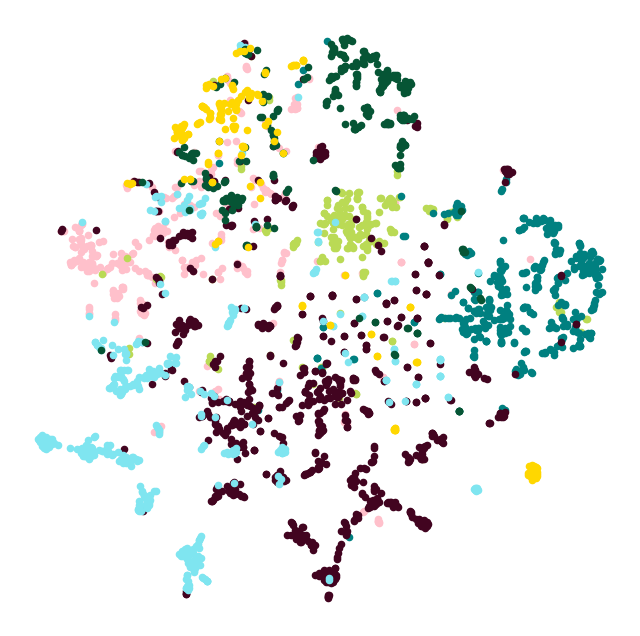

In [23]:
@torch.no_grad()
def plot_points(colors):
    model.eval()
    z = model(torch.arange(data.num_nodes, device=device))
    z = TSNE(n_components=2).fit_transform(z.cpu().numpy())
    y = data.y.cpu().numpy()

    plt.figure(figsize=(8, 8))
    for i in range(dataset.num_classes):
        plt.scatter(z[y == i, 0], z[y == i, 1], s=20, color=colors[i])
    plt.axis('off')
    plt.show()


colors = ['#ffc0cb', '#bada55', '#008080', '#420420', '#7fe5f0', '#065535', '#ffd700']
plot_points(colors)